# MinHash Similarity antar Jurnal

Studi kasus: tiga jurnal bertema **perpustakaan & temu kembali informasi**.

| Dokumen | Berkas | Judul ringkas |
|---|---|---|
| **D1** | `Jurnal1.pdf` | Perkembangan dan Peran OPAC pada Aplikasi CIP — Tridinanti Palembang (Elsadantia, 2023) |
| **D2** | `Jurnal2.pdf` | Pemanfaatan STKI menggunakan OPAC — Poltekkes Sorong (Nanlohy dkk., 2023) |
| **D3** | `Jurnal3.pdf` | Strategi Pustakawan dalam Shelving Koleksi — SMAN 2 Trenggalek (Fatoni & Handayani, FIHRIS 2024) |

## Aturan implementasi (dari dosen)
1. **Setiap jurnal utuh = 1 dokumen** (D1, D2, D3) — bukan dipecah jadi paragraf.
2. **RegEx memotong bab**: ambil isi mulai `PENDAHULUAN` sampai sebelum `KESIMPULAN`/`PENUTUP`/`SIMPULAN`/`DAFTAR PUSTAKA`. Bila tidak ada penanda bab, ambil seluruh teks (fallback).
3. **Scoring antar-jurnal**: bangun shingle set tiap jurnal → Min-Hash signature → estimasi Jaccard similarity antar D1, D2, D3.

## Pipeline notebook
1. **Ekstraksi 3 PDF → raw text** (pdfplumber, fungsi generik tanpa hard-code per-jurnal)
2. **RegEx memotong bab** tiap jurnal (multi-pola + fallback fleksibel)
3. **Korpus dokumen**: D1, D2, D3 = isi bab tiap jurnal
4. **Preprocessing** (case folding → cleaning → tokenizing → stopword removal → stemming)
5. **Pembangunan Shingle Set** (k-shingle dari token)
6. **Min-Hash Signature Matrix** (fungsi hash acak universal)
7. **Jaccard Similarity Eksak** (ground truth)
8. **Estimasi Jaccard Similarity** dari signature Min-Hash
9. **LSH Banding** (deteksi kandidat pasangan mirip)
10. **Analisis akurasi** terhadap jumlah fungsi hash + ringkasan


## 0. Install dependencies (sekali saja)

In [1]:
# Pasang library yang dibutuhkan (jalankan sekali di environment baru / Colab)
!pip install -q pdfplumber PySastrawi numpy pandas

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import math
import re
import hashlib
import random
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

print('Import dan konfigurasi selesai. Teks tabel tidak dipotong.')


Import dan konfigurasi selesai. Teks tabel tidak dipotong.


## LANGKAH 1 — Ekstraksi 3 PDF jurnal menjadi raw text

Kita memproses tiga jurnal sekaligus: `Jurnal1.pdf`, `Jurnal2.pdf`, `Jurnal3.pdf`.
Setiap jurnal punya header / footer berbeda (judul publikasi, ISSN, nama penulis,
nomor halaman), jadi fungsi ekstraksi dibuat **generik** — tidak ada lagi pola
sampah yang spesifik per-jurnal seperti versi lama. Filter generik yang dipakai:

* Buang baris dengan panjang `< 10` karakter (sisa noise OCR / fragmen header).
* Buang baris yang isinya hanya angka (nomor halaman / footer numerik).
* Indentasi `x0 > 125` → awal paragraf baru.

Output Langkah 1 adalah dict `{D1: teks1, D2: teks2, D3: teks3}` berisi raw text
masing-masing jurnal lengkap dengan separator `\n\n` antar paragraf.

In [3]:
DAFTAR_JURNAL = {
    'D1': 'Jurnal1.pdf',
    'D2': 'Jurnal2.pdf',
    'D3': 'Jurnal3.pdf',
}


def ekstrak_pdf_jadi_raw_text(path_pdf: str) -> str:
    """Ekstrak PDF jurnal jadi 1 string raw text dengan paragraf dipisah \\n\\n.

    Strategi generik (TIDAK hard-code pola per-jurnal):
      - Posisi `x0` mendeteksi indent → awal paragraf baru.
      - Pola UPPERCASE pendek mendeteksi header bab (PENDAHULUAN, METODE, dll.).
      - Filter generik: buang baris < 10 karakter, buang baris yang isinya
        hanya angka (footer / nomor halaman).
    """
    BATAS_INDENT = 125
    bagian_paragraf: list[str] = []
    buffer = ''

    def flush():
        nonlocal buffer
        if buffer.strip():
            bagian_paragraf.append(buffer.strip())
        buffer = ''

    pola_header_bab = re.compile(r'^[A-Z][A-Z\s]{3,40}$')
    pola_hanya_angka = re.compile(r'^\s*\d+\s*$')

    with pdfplumber.open(path_pdf) as pdf:
        for hal in pdf.pages:
            for ln in hal.extract_text_lines():
                teks_baris = ln['text'].strip()
                if len(teks_baris) < 10:
                    continue
                if pola_hanya_angka.match(teks_baris):
                    continue

                terindentasi = ln['x0'] > BATAS_INDENT
                header_bab = bool(pola_header_bab.match(teks_baris))

                if terindentasi or header_bab:
                    flush()
                    buffer = teks_baris
                    if header_bab:
                        flush()
                else:
                    buffer = (buffer + ' ' + teks_baris).strip()
    flush()

    return '\n\n'.join(bagian_paragraf)


teks_jurnal = {
    doc_id: ekstrak_pdf_jadi_raw_text(path)
    for doc_id, path in DAFTAR_JURNAL.items()
}

print(f'{"Dokumen":<10}{"Berkas":<15}{"Karakter":>12}')
print('=' * 37)
for doc_id, path in DAFTAR_JURNAL.items():
    print(f'{doc_id:<10}{path:<15}{len(teks_jurnal[doc_id]):>12,}')

print('\n' + '=' * 78)
print(f'CUPLIKAN 500 KARAKTER PERTAMA D1 ({DAFTAR_JURNAL["D1"]}):')
print('=' * 78)
print(teks_jurnal['D1'][:500])
print('\n' + '=' * 78)
print(f'CUPLIKAN 500 KARAKTER PERTAMA D2 ({DAFTAR_JURNAL["D2"]}):')
print('=' * 78)
print(teks_jurnal['D2'][:500])
print('\n' + '=' * 78)
print(f'CUPLIKAN 500 KARAKTER PERTAMA D3 ({DAFTAR_JURNAL["D3"]}):')
print('=' * 78)
print(teks_jurnal['D3'][:500])

Dokumen   Berkas             Karakter
D1        Jurnal1.pdf          25,110
D2        Jurnal2.pdf          15,347
D3        Jurnal3.pdf          35,802

CUPLIKAN 500 KARAKTER PERTAMA D1 (Jurnal1.pdf):
PERKEMBANGAN DAN PERAN OPAC PADA APLIKASI CIP

(CERAH INFORMASI PUSTAKA) UNTUK TEMU KEMBALI INFORMASI

DI PERPUSTAKAAN UNIVERSITAS TRIDINANTI PALEMBANG

Betari Ayu Elsadantia

Prodi Ilmu Perpustakaan, Fakultas Adab dan Humaniora, UIN Raden Fatah Palembang

Email: betariayu2511@gmail.com ARTICLE HISTORY Abstrak Received: Penelitian ini membahas mengenai Perkembangan dan Peran OPAC Pada Aplikasi CIP (Cerah 12 Oktober 2023 Informasi Pustaka) untuk temu kembali informasi yang ada di Perpustakaan Tri

CUPLIKAN 500 KARAKTER PERTAMA D2 (Jurnal2.pdf):
JURNAL ACTA DIURNA KOMUNIKASI

Vol. 5 Nomor 2, 2023 [e-ISSN 2685 6999] _________________________________________________________________________

Pemanfaatan Sistem Sistem Simpan Temu Kembali Informasi

menggunakan Online Public Acces Catalog (Opac)

## LANGKAH 2 — RegEx memotong bab tiap jurnal

Tiap jurnal pakai konvensi penutup yang berbeda — `KESIMPULAN`, `PENUTUP`,
`SIMPULAN`, atau hanya `DAFTAR PUSTAKA`. Karena itu RegEx mencoba beberapa pola
secara berurutan dan memakai yang **pertama berhasil match**:

1. `PENDAHULUAN ... KESIMPULAN`
2. `PENDAHULUAN ... PENUTUP`
3. `PENDAHULUAN ... SIMPULAN`
4. `PENDAHULUAN ... DAFTAR PUSTAKA`

Bila keempat pola gagal (misal jurnal tanpa penanda bab eksplisit), kita pakai
**fallback**: ambil seluruh raw text apa adanya. Bagian Abstrak dan
Daftar Pustaka idealnya terbuang otomatis selama RegEx pertama berhasil match.

In [4]:
# ---- REGEX UTAMA: cari isi mulai 'PENDAHULUAN' sampai sebelum penanda akhir bab.
# Catatan penting: regex pakai \b word-boundary (tidak butuh newline) supaya juga
# match format inline 'A. PENDAHULUAN ... A. Kesimpulan'. Tapi case-sensitive
# (TANPA re.IGNORECASE) supaya tidak salah match kata 'kesimpulan' lowercase
# yang muncul di tengah kalimat body text. Kita izinkan dua variasi capitalization
# untuk penanda akhir: ALL CAPS (header gaya umum) dan Title Case (gaya Acta Diurna).
POLA_AKHIR_BAB = [
    ('KESIMPULAN', 'Kesimpulan'),
    ('PENUTUP', 'Penutup'),
    ('SIMPULAN', 'Simpulan'),
    ('DAFTAR PUSTAKA', 'Daftar Pustaka'),
]


def potong_bab(teks: str) -> tuple[str, str]:
    """Potong bab PENDAHULUAN..(akhir) dari teks jurnal.

    Returns:
        (isi_bab, label_pola) — label_pola = 'PENDAHULUAN..KESIMPULAN' dst,
                                 atau 'fallback (seluruh teks)' bila tak match.
    """
    for variants in POLA_AKHIR_BAB:
        alt = '|'.join(re.escape(v) for v in variants)
        pola = re.compile(
            rf'\bPENDAHULUAN\b(.*?)\b(?:{alt})\b',
            flags=re.DOTALL,  # NO IGNORECASE — supaya hanya match header beneran
        )
        m = pola.search(teks)
        if m:
            return m.group(1).strip(), f'PENDAHULUAN..{variants[0]}'
    return teks.strip(), 'fallback (seluruh teks)'


hasil_potong = {doc_id: potong_bab(teks) for doc_id, teks in teks_jurnal.items()}

print(f'{"Dok":<5}{"Pola RegEx terpilih":<35}{"Sebelum":>12}{"Sesudah":>12}')
print('=' * 64)
for doc_id, (isi, pola_label) in hasil_potong.items():
    n_sebelum = len(teks_jurnal[doc_id])
    n_sesudah = len(isi)
    print(f'{doc_id:<5}{pola_label:<35}{n_sebelum:>12,}{n_sesudah:>12,}')

# Cuplikan tiap dokumen hasil potong
for doc_id, (isi, _) in hasil_potong.items():
    print('\n' + '=' * 78)
    print(f'CUPLIKAN 300 KARAKTER PERTAMA {doc_id} (hasil potong bab):')
    print('=' * 78)
    print(isi[:300], '...')

Dok  Pola RegEx terpilih                     Sebelum     Sesudah
D1   PENDAHULUAN..KESIMPULAN                  25,110      17,401
D2   PENDAHULUAN..KESIMPULAN                  15,347       8,445
D3   PENDAHULUAN..KESIMPULAN                  35,802      12,044

CUPLIKAN 300 KARAKTER PERTAMA D1 (hasil potong bab):
Dunia saat ini sangatlah bergantung terhadap yang namanya teknologi. Di zaman yang serba modern ini manusia diharuskan untuk memahami perkembangan teknologi yang terjadi, salah satunya ialah teknologi informasi. Perkembangan teknologi ini banyak dilakukan di sebuah perusahaan maupun lembaga informas ...

CUPLIKAN 300 KARAKTER PERTAMA D2 (hasil potong bab):
Era digitalisasi saat ini berkembang sangat pesat dan bertransformasi sesuai keadaan dan situasi. Bahkan lembaga pemerintah turut merasakan transformasi digital yang berkembang. Salah satu lembaga pemerintah yang bergerak dibidang informasi dan turut merasakan tranformasi digital yaitu perpustakaan. ...

CUPLIKAN 300 KARAKTER

## LANGKAH 3 — Korpus dokumen (1 jurnal = 1 dokumen)

Setelah RegEx, **isi bab tiap jurnal langsung menjadi 1 dokumen**: D1, D2, D3.
Tidak ada lagi pemecahan paragraf — paradigmanya adalah membandingkan kemiripan
antar-**jurnal** (bukan antar-paragraf dalam 1 jurnal).

| Dokumen | Sumber |
|---|---|
| D1 | Jurnal 1 — OPAC Tridinanti Palembang (Elsadantia, 2023) |
| D2 | Jurnal 2 — OPAC Poltekkes Sorong (Nanlohy dkk., 2023) |
| D3 | Jurnal 3 — Shelving Koleksi SMAN 2 Trenggalek (Fatoni & Handayani, FIHRIS 2024) |

In [5]:
# Setiap jurnal utuh = 1 dokumen. Tidak ada split paragraf.
dokumen = {doc_id: isi for doc_id, (isi, _) in hasil_potong.items()}
label_dokumen = {
    'D1': 'Jurnal 1 — OPAC Tridinanti Palembang (Elsadantia, 2023)',
    'D2': 'Jurnal 2 — OPAC Poltekkes Sorong (Nanlohy dkk., 2023)',
    'D3': 'Jurnal 3 — Shelving Koleksi SMAN 2 Trenggalek (FIHRIS, 2024)',
}

print(f'Total dokumen: {len(dokumen)}')
print('=' * 78)
df_korpus = pd.DataFrame({
    'Dokumen': list(dokumen.keys()),
    'Label Jurnal': [label_dokumen[d] for d in dokumen.keys()],
    'Karakter': [len(t) for t in dokumen.values()],
    'Cuplikan 200 karakter pertama': [t[:200] + ' ...' for t in dokumen.values()],
})
display(df_korpus)

Total dokumen: 3


,Dokumen,Label Jurnal,Karakter,Cuplikan 200 karakter pertama
0,D1,"Jurnal 1 — OPAC Tridinanti Palembang (Elsadantia, 2023)",17401,"Dunia saat ini sangatlah bergantung terhadap yang namanya teknologi. Di zaman yang serba modern ini manusia diharuskan untuk memahami perkembangan teknologi yang terjadi, salah satunya ialah teknologi ..."
1,D2,"Jurnal 2 — OPAC Poltekkes Sorong (Nanlohy dkk., 2023)",8445,Era digitalisasi saat ini berkembang sangat pesat dan bertransformasi sesuai keadaan dan situasi. Bahkan lembaga pemerintah turut merasakan transformasi digital yang berkembang. Salah satu lembaga pem ...
2,D3,"Jurnal 3 — Shelving Koleksi SMAN 2 Trenggalek (FIHRIS, 2024)",12044,"Shelving koleksi merupakan salah satu rangkaian program perpustakaan dalam memudahkan pengguna untuk melakukan temu kembali informasi. Sesuai dengan UU No.43 Tahun 2007 (Pasal 1) tentang perpustakaan, ..."


## Preprocessing

Pipeline `preprocess(text)`:
1. Case folding
2. Cleaning (regex: hapus angka dan tanda baca)
3. Tokenizing
4. Stopword Removal (`StopWordRemoverFactory`)
5. Stemming (`StemmerFactory`)

In [6]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    teks_tanpa_stopword = stopword_remover.remove(' '.join(tokens))
    tokens_tanpa_stopword = teks_tanpa_stopword.split()
    tokens_stem = [stemmer.stem(token) for token in tokens_tanpa_stopword]
    return tokens_stem

hasil_preproses = {nama_dok: preprocess(teks) for nama_dok, teks in dokumen.items()}

df_preproses = pd.DataFrame({
    'Dokumen': list(hasil_preproses.keys()),
    'Bagian Jurnal': [label_dokumen[d] for d in hasil_preproses.keys()],
    'Token Hasil Preprocessing': [' '.join(v) for v in hasil_preproses.values()]
})
display(df_preproses)

Dokumen                                                 Bagian Jurnal                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [7]:
# ============================================================
# LANGKAH B — Shingling
# ============================================================
K_SHINGLE = 2  # ukuran shingle; coba juga 1 (unigram) atau 3 (trigram)

def buat_shingle(tokens: list, k: int) -> set:
    """
    Buat himpunan k-shingle dari list token.
    Shingle direpresentasikan sebagai tuple (immutable) agar bisa masuk set.
    """
    if len(tokens) < k:
        # Jika token lebih sedikit dari k, pakai unigram
        return {tuple(tokens)}
    return {tuple(tokens[i:i+k]) for i in range(len(tokens) - k + 1)}

# Buat shingle set untuk setiap dokumen
shingle_set = {
    dok: buat_shingle(tokens, K_SHINGLE)
    for dok, tokens in hasil_preproses.items()
}

# Daftar nama dokumen (urut sesuai dokumen) untuk dipakai di langkah berikutnya
nama_dokumen = list(shingle_set.keys())

# Tampilkan ringkasan
print(f'K-Shingle: {K_SHINGLE}')
print('=' * 60)
df_shingle = pd.DataFrame({
    'Dokumen': list(shingle_set.keys()),
    'Jumlah Token': [len(hasil_preproses[d]) for d in shingle_set.keys()],
    'Jumlah Shingle Unik': [len(s) for s in shingle_set.values()],
    'Contoh Shingle (3 pertama)': [
        str(list(shingle_set[d])[:3]) for d in shingle_set.keys()
    ]
})
display(df_shingle)

# Universal shingle universe (gabungan semua shingle)
universe = sorted({s for sset in shingle_set.values() for s in sset})
shingle_index = {s: i for i, s in enumerate(universe)}  # mapping shingle → indeks integer
print(f'\nUkuran Universe Shingle: {len(universe)} shingle unik')


K-Shingle: 2


,Dokumen,Jumlah Token,Jumlah Shingle Unik,Contoh Shingle (3 pertama)
0,D1,1306,925,"[('akses', 'umum'), ('iring', 'kembang'), ('dekat', 'deskriptif')]"
1,D2,624,409,"[('informasi', 'fitur'), ('digital', 'guna'), ('simpul', 'uji')]"
2,D3,874,642,"[('laku', 'guna'), ('pola', 'data'), ('data', 'rangkum')]"



Ukuran Universe Shingle: 1849 shingle unik


## LANGKAH C — Jaccard Similarity Eksak (Rumus 1)

Ukuran kemiripan antar dua himpunan: rasio elemen yang sama (irisan) terhadap
total elemen unik (gabungan).

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

* $A$, $B$ = himpunan shingle dari dua dokumen
* Nilai $0$ = tidak ada shingle yang sama, $1$ = identik

Cell di bawah membangun matriks Jaccard eksak $3 \times 3$ sebagai **ground
truth** — referensi untuk mengevaluasi seberapa akurat estimasi Min-Hash di
LANGKAH E.

In [8]:
# ============================================================
# LANGKAH C — Jaccard Similarity Eksak
# ============================================================
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Hitung Jaccard Similarity eksak antara dua himpunan."""
    if not set_a and not set_b:
        return 1.0  # keduanya kosong → identik
    irisan = len(set_a & set_b)
    gabungan = len(set_a | set_b)
    return irisan / gabungan if gabungan > 0 else 0.0

# Hitung matriks Jaccard eksak
N_DOK = len(nama_dokumen)
matrix_jaccard_eksak = pd.DataFrame(
    index=nama_dokumen, columns=nama_dokumen, dtype=float
)

for di in nama_dokumen:
    for dj in nama_dokumen:
        matrix_jaccard_eksak.loc[di, dj] = jaccard_similarity(
            shingle_set[di], shingle_set[dj]
        )

print('MATRIKS JACCARD SIMILARITY EKSAK (Ground Truth)')
print('=' * 60)
display(matrix_jaccard_eksak.round(4))

MATRIKS JACCARD SIMILARITY EKSAK (Ground Truth)


,D1,D2,D3
D1,1.0000,0.0504,0.0336
D2,0.0504,1.0000,0.0264
D3,0.0336,0.0264,1.0000


## LANGKAH D — Hash Function & MinHash Signature (Rumus 2 & 3)

### Rumus 2 — Hash function universal

$$h(x) = (a \cdot x + b) \bmod p$$

* $a, b$ = bilangan acak konstan (berbeda untuk tiap fungsi hash)
* $p$ = bilangan prima besar (di code: `PRIME = 4_294_967_311`)
* $x$ = indeks integer dari shingle dalam universe

Kita generate $K$ pasang $(a, b)$ acak → menghasilkan $K$ fungsi hash berbeda
$h_1, h_2, \dots, h_K$. Bilangan prima besar dipakai supaya distribusi hash
mendekati uniform di seluruh range bilangan bulat.

### Rumus 3 — MinHash signature

$$\text{minhash}_k(S) = \min_{x \in S} h_k(x)$$

Untuk tiap fungsi hash $h_k$, ambil **nilai minimum** dari hasil hash pada
seluruh shingle dokumen $S$. Hasilnya: vektor signature panjang $K$ yang
"merangkum" set shingle dokumen — bayangkan seperti sidik jari ringkas.

Cell di bawah membangkitkan parameter $(a, b)$, mengimplementasikan kedua
rumus, lalu menyusun signature matrix $K \times N$ untuk semua dokumen.

In [9]:
# ============================================================
# LANGKAH D — Signature Matrix Min-Hash
# ============================================================
N_HASH = 100      # jumlah fungsi hash; makin besar = makin akurat
PRIME = 4294967311  # bilangan prima besar (> ukuran universe yang mungkin)

random.seed(42)  # untuk reprodusibilitas

# Generate n pasang (a, b) acak untuk fungsi hash h(x) = (a*x + b) mod PRIME
params_hash = [
    (random.randint(1, PRIME - 1), random.randint(0, PRIME - 1))
    for _ in range(N_HASH)
]

def minhash_signature(shingle_indices: list, params: list, prime: int) -> list:
    """
    Hitung signature Min-Hash dari sebuah dokumen.

    Args:
        shingle_indices: list indeks integer dari shingle dokumen ini
        params: list (a, b) untuk tiap fungsi hash
        prime: bilangan prima untuk modulo
    Returns:
        list nilai minimum hash (signature vector)
    """
    if not shingle_indices:
        return [0] * len(params)  # dokumen kosong

    signature = []
    for a, b in params:
        # Hitung h(x) = (a*x + b) mod p untuk setiap shingle, ambil minimum
        min_hash = min((a * x + b) % prime for x in shingle_indices)
        signature.append(min_hash)
    return signature

# Konversi shingle set ke indeks integer
shingle_indices_per_dok = {
    dok: [shingle_index[s] for s in sset]
    for dok, sset in shingle_set.items()
}

# Hitung signature untuk setiap dokumen
signatures = {
    dok: minhash_signature(shingle_indices_per_dok[dok], params_hash, PRIME)
    for dok in nama_dokumen
}

# Tampilkan signature matrix (10 hash pertama)
print(f'Signature Matrix Min-Hash (N_HASH={N_HASH}, ditampilkan 10 pertama)')
print('=' * 70)
df_signature = pd.DataFrame(
    {dok: signatures[dok][:10] for dok in nama_dokumen},
    index=[f'h{i+1}' for i in range(10)]
)
display(df_signature)

Signature Matrix Min-Hash (N_HASH=100, ditampilkan 10 pertama)


,D1,D2,D3
h1,215571,3543720,5199751
h2,4259038,2555127,851216
h3,4724563,5284601,11300018
h4,458643,479890,15876475
h5,141832,7408477,8538395
h6,5601440,2952501,303562
h7,11780913,8559807,1364006
h8,1596866,800820,2392912
h9,1209286,3682827,16604496
h10,1906612,19320121,8494637


## LANGKAH E — Estimasi Jaccard via MinHash (Rumus 4)

Trik utama Min-Hash: probabilitas dua dokumen punya **nilai signature sama** di
fungsi hash ke-$k$ secara matematis sama dengan Jaccard similarity-nya. Jadi
cukup hitung proporsi posisi yang cocok antar dua signature.

$$\hat{J}(A, B) = \frac{1}{K} \sum_{k=1}^{K} \mathbb{1}\bigl[\text{minhash}_k(A) = \text{minhash}_k(B)\bigr]$$

* $K$ = jumlah fungsi hash (di code: `N_HASH`)
* $\mathbb{1}[\cdot]$ = fungsi indikator (bernilai $1$ jika benar, $0$ jika salah)
* $\hat{J}$ = estimasi Jaccard dari signature

Semakin besar $K$, estimasi makin mendekati nilai eksak — properti ini akan
dibuktikan secara empiris di LANGKAH H. Cell di bawah menghitung matriks
estimasi $3 \times 3$ sekaligus membandingkannya dengan ground truth (Rumus 1).

In [10]:
# ============================================================
# LANGKAH E — Estimasi Jaccard Similarity dari Signature
# ============================================================
def estimasi_jaccard_minhash(sig_a: list, sig_b: list) -> float:
    """Estimasi Jaccard Similarity dari dua signature Min-Hash."""
    cocok = sum(1 for ha, hb in zip(sig_a, sig_b) if ha == hb)
    return cocok / len(sig_a)

# Bangun matriks estimasi Min-Hash
matrix_minhash = pd.DataFrame(
    index=nama_dokumen, columns=nama_dokumen, dtype=float
)

for di in nama_dokumen:
    for dj in nama_dokumen:
        matrix_minhash.loc[di, dj] = estimasi_jaccard_minhash(
            signatures[di], signatures[dj]
        )

print(f'MATRIKS ESTIMASI JACCARD (Min-Hash, N_HASH={N_HASH})')
print('=' * 60)
display(matrix_minhash.round(4))

# Hitung error estimasi
print('\nPERBANDINGAN EKSAK vs ESTIMASI (pasangan unik)')
print('=' * 75)
rows_perbandingan = []
for di, dj in itertools.combinations(nama_dokumen, 2):
    eksak = matrix_jaccard_eksak.loc[di, dj]
    estimasi = matrix_minhash.loc[di, dj]
    error = abs(eksak - estimasi)
    rows_perbandingan.append({
        'Pasangan': f'{di} – {dj}',
        'Jaccard Eksak': round(eksak, 4),
        'Estimasi Min-Hash': round(estimasi, 4),
        'Error Absolut': round(error, 4)
    })

df_perbandingan = pd.DataFrame(rows_perbandingan)
display(df_perbandingan)
print(f'\nRata-rata Error Absolut: {df_perbandingan["Error Absolut"].mean():.4f}')
print(f'Error Maksimum        : {df_perbandingan["Error Absolut"].max():.4f}')

MATRIKS ESTIMASI JACCARD (Min-Hash, N_HASH=100)


,D1,D2,D3
D1,1.00,0.05,0.01
D2,0.05,1.00,0.03
D3,0.01,0.03,1.00



PERBANDINGAN EKSAK vs ESTIMASI (pasangan unik)


,Pasangan,Jaccard Eksak,Estimasi Min-Hash,Error Absolut
0,D1 – D2,0.0504,0.05,0.0004
1,D1 – D3,0.0336,0.01,0.0236
2,D2 – D3,0.0264,0.03,0.0036



Rata-rata Error Absolut: 0.0092
Error Maksimum        : 0.0236


In [11]:
# ============================================================
# LANGKAH F — LSH Banding
# ============================================================
B = 10   # jumlah band
R = N_HASH // B  # jumlah baris per band (harus habis dibagi)

assert N_HASH % B == 0, f'N_HASH ({N_HASH}) harus habis dibagi B ({B})'

threshold_lsh = (1 / B) ** (1 / R)
print(f'Konfigurasi LSH: B={B} band, R={R} baris/band')
print(f'Threshold similaritas ≈ {threshold_lsh:.4f}')
print('(Pasangan dengan Jaccard > threshold kemungkinan besar akan terdeteksi)')
print('=' * 60)

def lsh_banding(signatures: dict, b: int, r: int) -> set:
    """
    Temukan kandidat pasangan dokumen mirip menggunakan LSH Banding.

    Returns:
        Set of tuple (dokA, dokB) yang merupakan kandidat mirip.
    """
    kandidat = set()
    nama_dok_list = list(signatures.keys())

    for band_idx in range(b):
        # Bucket untuk band ini: hash(signature band) → list dokumen
        bucket = {}
        for dok, sig in signatures.items():
            # Ambil potongan signature untuk band ini
            awal = band_idx * r
            akhir = awal + r
            band_sig = tuple(sig[awal:akhir])

            # Hash tuple ke bucket
            kunci = hash(band_sig)  # Python built-in hash
            bucket.setdefault(kunci, []).append(dok)

        # Dokumen dalam bucket yang sama = kandidat
        for dok_dalam_bucket in bucket.values():
            if len(dok_dalam_bucket) > 1:
                for pasangan in itertools.combinations(dok_dalam_bucket, 2):
                    kandidat.add(tuple(sorted(pasangan)))

    return kandidat

kandidat_mirip = lsh_banding(signatures, B, R)

# Verifikasi kandidat dengan Jaccard eksak
print(f'Total kandidat pasangan ditemukan LSH: {len(kandidat_mirip)}')
print()

if kandidat_mirip:
    rows_lsh = []
    for di, dj in sorted(kandidat_mirip):
        sim_eksak = matrix_jaccard_eksak.loc[di, dj]
        sim_estimasi = matrix_minhash.loc[di, dj]
        rows_lsh.append({
            'Pasangan Kandidat': f'{di} – {dj}',
            'Jaccard Eksak': round(sim_eksak, 4),
            'Estimasi Min-Hash': round(sim_estimasi, 4),
            'Status': '✅ Mirip' if sim_eksak >= threshold_lsh else '⚠️ False Positive'
        })
    df_lsh = pd.DataFrame(rows_lsh)
    display(df_lsh)
else:
    print('Tidak ada kandidat pasangan terdeteksi pada threshold ini.')
    print(f'Coba turunkan threshold dengan memperbesar B atau perkecil R.')

Konfigurasi LSH: B=10 band, R=10 baris/band
Threshold similaritas ≈ 0.7943
(Pasangan dengan Jaccard > threshold kemungkinan besar akan terdeteksi)
Total kandidat pasangan ditemukan LSH: 0

Tidak ada kandidat pasangan terdeteksi pada threshold ini.
Coba turunkan threshold dengan memperbesar B atau perkecil R.


ANALISIS AKURASI vs JUMLAH FUNGSI HASH


,N_Hash,Pasangan,Jaccard Eksak,Estimasi,Error
0,10,D1–D2,0.0504,0.000,0.0504
1,10,D1–D3,0.0336,0.000,0.0336
2,10,D2–D3,0.0264,0.000,0.0264
3,25,D1–D2,0.0504,0.000,0.0504
4,25,D1–D3,0.0336,0.000,0.0336
5,25,D2–D3,0.0264,0.040,0.0136
6,50,D1–D2,0.0504,0.040,0.0104
7,50,D1–D3,0.0336,0.020,0.0136
8,50,D2–D3,0.0264,0.020,0.0064
9,100,D1–D2,0.0504,0.050,0.0004


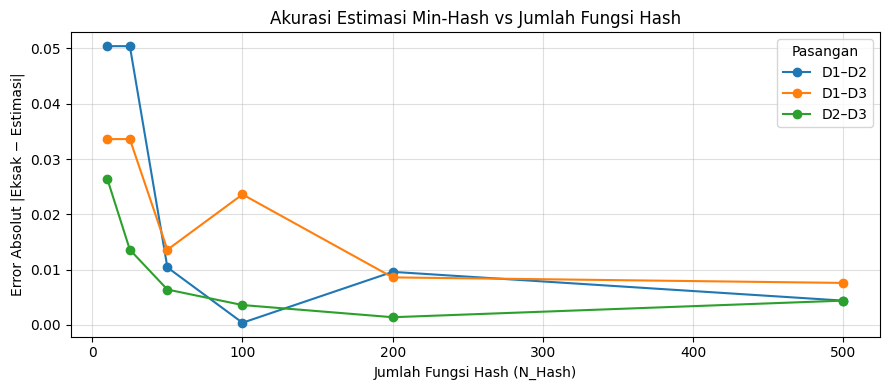

Plot disimpan sebagai minhash_akurasi.png


In [12]:
# ============================================================
# LANGKAH H — Analisis pengaruh N_HASH terhadap akurasi estimasi
# ============================================================
n_hash_list = [10, 25, 50, 100, 200, 500]

# Ambil satu pasangan dokumen representatif (D1 dan D2)
pasangan_uji = list(itertools.combinations(nama_dokumen[:min(4, len(nama_dokumen))], 2))

print('ANALISIS AKURASI vs JUMLAH FUNGSI HASH')
print('=' * 70)

rows_analisis = []
for n in n_hash_list:
    random.seed(42)
    params_n = [
        (random.randint(1, PRIME - 1), random.randint(0, PRIME - 1))
        for _ in range(n)
    ]
    sigs_n = {
        dok: minhash_signature(shingle_indices_per_dok[dok], params_n, PRIME)
        for dok in nama_dokumen
    }
    for di, dj in pasangan_uji:
        eksak = matrix_jaccard_eksak.loc[di, dj]
        estimasi = estimasi_jaccard_minhash(sigs_n[di], sigs_n[dj])
        rows_analisis.append({
            'N_Hash': n,
            'Pasangan': f'{di}–{dj}',
            'Jaccard Eksak': round(float(eksak), 4),
            'Estimasi': round(estimasi, 4),
            'Error': round(abs(float(eksak) - estimasi), 4)
        })

df_analisis = pd.DataFrame(rows_analisis)
display(df_analisis)

# Plot error vs N_HASH
fig, ax = plt.subplots(figsize=(9, 4))
for pasangan in df_analisis['Pasangan'].unique():
    subset = df_analisis[df_analisis['Pasangan'] == pasangan]
    ax.plot(subset['N_Hash'], subset['Error'], marker='o', label=pasangan)

ax.set_xlabel('Jumlah Fungsi Hash (N_Hash)')
ax.set_ylabel('Error Absolut |Eksak − Estimasi|')
ax.set_title('Akurasi Estimasi Min-Hash vs Jumlah Fungsi Hash')
ax.legend(title='Pasangan', loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('minhash_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai minhash_akurasi.png')

In [13]:
# ============================================================
# LANGKAH I — Ringkasan & Kesimpulan
# ============================================================
print('=' * 70)
print('RINGKASAN IMPLEMENTASI MIN-HASH ANTAR-JURNAL')
print('=' * 70)
print(f'Dokumen     : {len(nama_dokumen)} jurnal ({", ".join(nama_dokumen)})')
print(f'K-Shingle   : {K_SHINGLE} (bigram token)')
print(f'Universe    : {len(universe)} shingle unik')
print(f'N_Hash      : {N_HASH} fungsi hash')
print(f'LSH Config  : B={B} band × R={R} baris/band')
print(f'Threshold   : {threshold_lsh:.4f}')
print()

# Tampilkan semua pasangan jurnal terurut dari paling mirip
print('PASANGAN JURNAL (urut dari paling mirip, berdasarkan Jaccard Eksak):')
print('-' * 70)
rows_top = []
for di, dj in itertools.combinations(nama_dokumen, 2):
    eksak = float(matrix_jaccard_eksak.loc[di, dj])
    estimasi = float(matrix_minhash.loc[di, dj])
    rows_top.append({
        'Pasangan': f'{di} – {dj}',
        'Jaccard Eksak': round(eksak, 4),
        'Min-Hash Estimasi': round(estimasi, 4),
        'Error': round(abs(eksak - estimasi), 4)
    })

df_top = pd.DataFrame(rows_top).sort_values('Jaccard Eksak', ascending=False)
display(df_top.reset_index(drop=True))

print()
print('KESIMPULAN:')
mean_error = df_perbandingan['Error Absolut'].mean()
print(f'• Rata-rata error estimasi Min-Hash: {mean_error:.4f}')
print(f'• Makin besar N_Hash → makin kecil error (lihat Langkah H)')
print(f'• LSH menemukan {len(kandidat_mirip)} kandidat pasangan mirip')
print(f'  di atas threshold {threshold_lsh:.4f}')

RINGKASAN IMPLEMENTASI MIN-HASH ANTAR-JURNAL
Dokumen     : 3 jurnal (D1, D2, D3)
K-Shingle   : 2 (bigram token)
Universe    : 1849 shingle unik
N_Hash      : 100 fungsi hash
LSH Config  : B=10 band × R=10 baris/band
Threshold   : 0.7943

PASANGAN JURNAL (urut dari paling mirip, berdasarkan Jaccard Eksak):
----------------------------------------------------------------------


,Pasangan,Jaccard Eksak,Min-Hash Estimasi,Error
0,D1 – D2,0.0504,0.05,0.0004
1,D1 – D3,0.0336,0.01,0.0236
2,D2 – D3,0.0264,0.03,0.0036



KESIMPULAN:
• Rata-rata error estimasi Min-Hash: 0.0092
• Makin besar N_Hash → makin kecil error (lihat Langkah H)
• LSH menemukan 0 kandidat pasangan mirip
  di atas threshold 0.7943
